**Import libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


**Load data**

In [2]:
sales = pd.read_csv('/content/drive/My Drive/Sales.csv')
sales.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


**Data Preprocessing**

In [3]:
# Check null values
sales.isnull().sum()

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


In [4]:
# Convert date
sales['Date'] = pd.to_datetime(sales['Date'])

In [7]:
# Check and remove duplicates
sales.duplicated().sum()
sales = sales.drop_duplicates()
sales

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [8]:
# Check Revenue values
sales['calc_revenue'] = sales['Unit_Price'] * sales['Order_Quantity']
sales[['Revenue', 'calc_revenue']].head()

,Revenue,calc_revenue
0,950,960
1,950,960
2,2401,2760
3,2088,2400
4,418,480


In [9]:
# Comparison of discrepancies
sales['Diff'] = sales['Revenue'] - sales['calc_revenue']
sales.describe()

,Date,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,calc_revenue,Diff
count,112036,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000
mean,2014-11-23 05:22:32.008282880,15.665607,2014.400925,35.919508,11.904254,267.819603,453.850628,286.035194,471.103333,757.138527,845.162162,-88.023635
min,2011-01-01 00:00:00,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000,2.000000,-11062.000000
25%,2013-12-22 00:00:00,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,64.000000,70.000000,-73.000000
50%,2014-06-27 00:00:00,16.000000,2014.000000,35.000000,10.000000,9.000000,25.000000,103.000000,112.000000,226.000000,245.000000,-15.000000
75%,2016-01-09 00:00:00,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,360.000000,442.000000,806.000000,900.000000,-3.000000
max,2016-07-31 00:00:00,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000,69136.000000,0.000000
std,NaN,8.781485,1.273327,11.016543,9.564877,550.218722,922.751848,454.852634,886.971635,1312.061623,1469.637711,208.459456


In [10]:
# Fix Revenue and Profit values
sales['Revenue'] = sales['calc_revenue']
sales = sales.drop(columns=['calc_revenue', 'Diff'])
sales['Profit'] = sales['Revenue'] - sales['Cost']
sales

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,600,360,960
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,600,360,960
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1725,1035,2760
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1500,900,2400
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,300,180,480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,120,72,192
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,880,528,1408
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,880,528,1408
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,960,576,1536


In [11]:
# Create Profit_Margin column
sales['Profit_Margin'] = sales['Profit'] / sales['Revenue']
sales

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Profit_Margin
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,600,360,960,0.625
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,600,360,960,0.625
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1725,1035,2760,0.625
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1500,900,2400,0.625
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,300,180,480,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,120,72,192,0.625
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,880,528,1408,0.625
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,880,528,1408,0.625
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,960,576,1536,0.625


**Exploratory Data Analysis**

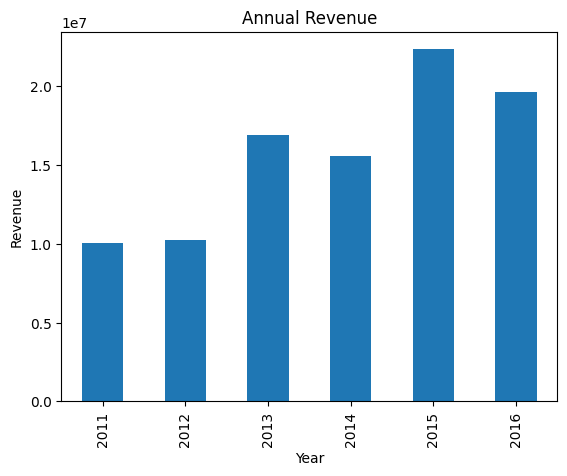

In [12]:
# Annual revenue
sales['Year'] = sales['Date'].dt.year
revenue_by_year = sales.groupby('Year')['Revenue'].sum()
revenue_by_year.plot(kind='bar', title='Annual Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

- Revenue showed strong growth from 2011 to 2015.

- There was a slight drop in 2014.

- 2015 was the year with the highest revenue.

- A slight decrease in 2016 but still maintaining a high level.

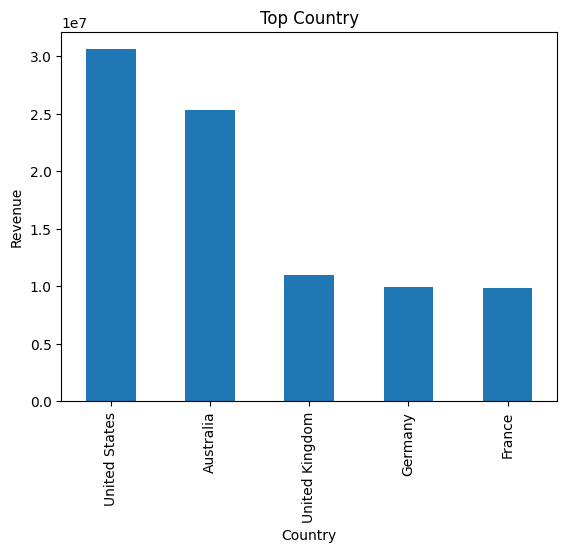

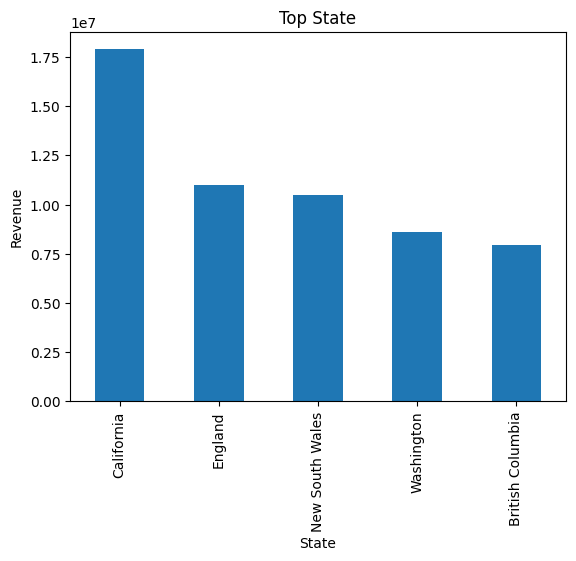

In [13]:
# Top Country/ State
top_country = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
top_country.plot(kind='bar', title='Top Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

top_state = sales.groupby('State')['Revenue'].sum().sort_values(ascending=False).head(5)
top_state.plot(kind='bar', title='Top State')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

**Top Country**
- The United States is the largest market, contributing the majority of revenue.

- The top 2 countries (US + Australia) account for the majority of revenue.

- European markets (Germany, France) have lower revenue → potential for expansion.

**Top State**
- California is the region generating the highest revenue.

- The top states all belongs to US, UK, Australia → Suitable for top countries

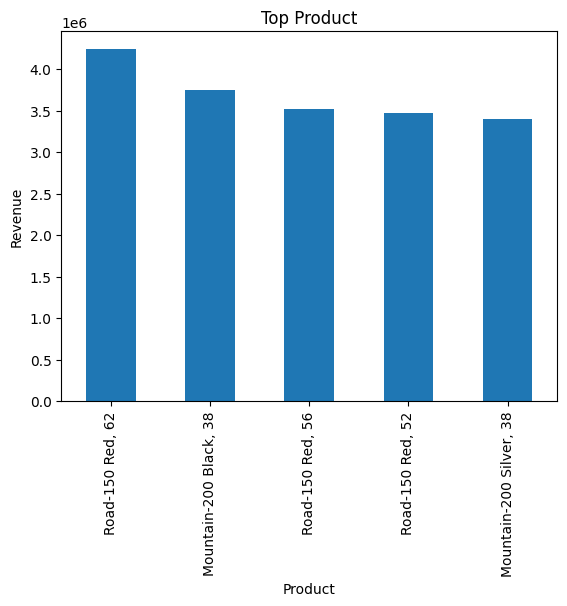

In [14]:
# Top Product
top_product = sales.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)
top_product.plot(kind='bar', title='Top Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

- The Road-150 Red line appears multiple times in the top → this is the best-selling product line.

- The same product but in different sizes (52, 56, 62) are all in the top → demand is evenly distributed across sizes.

- Top products belong to two main categories: Road Bikes, Mountain Bikes.

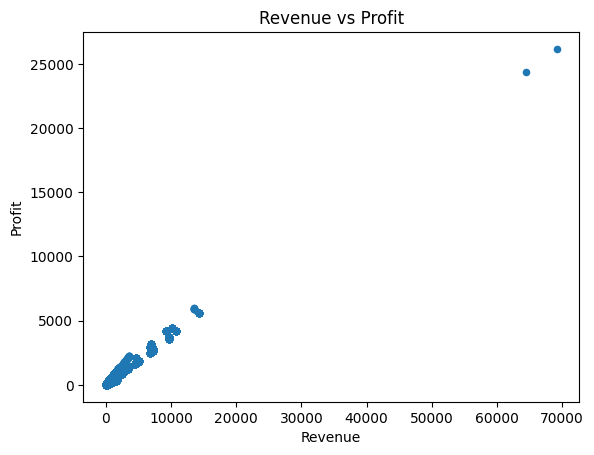

In [15]:
# Profit and Revenue
sales.plot.scatter(x='Revenue', y='Profit', title='Revenue vs Profit')
plt.show()

- Positive Correlation: Profit increases proportionally with revenue. → The business model has a stable and healthy profit margin.

- The vast majority of transactions are concentrated in the low-value group.

- Exceptional orders with extremely high revenue appear.


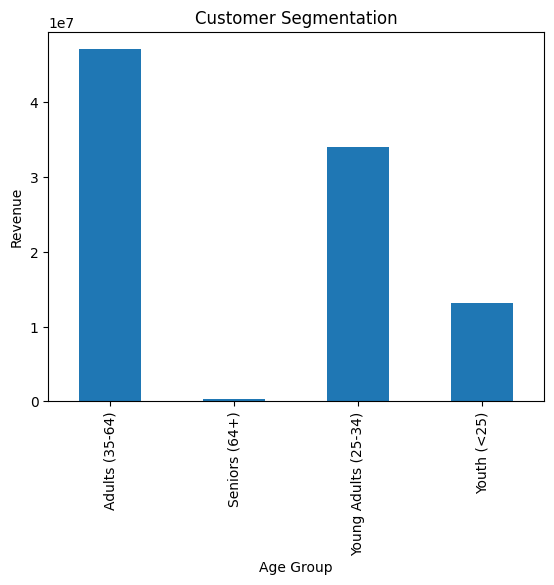

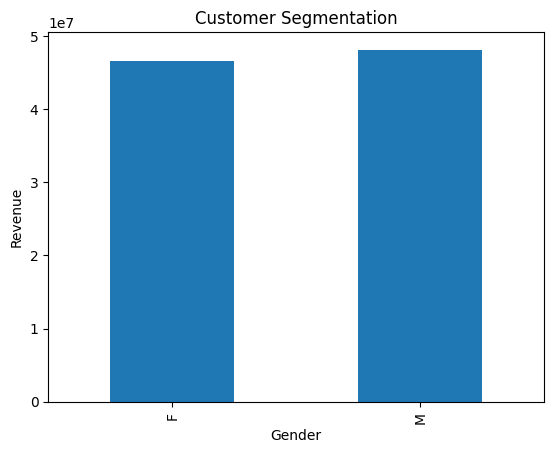

In [16]:
# Customer Segmentation
sales.groupby('Age_Group')['Revenue'].sum().plot(kind='bar', title='Customer Segmentation')
plt.xlabel('Age Group')
plt.ylabel('Revenue')
plt.show()

sales.groupby('Customer_Gender')['Revenue'].sum().plot(kind='bar', title='Customer Segmentation')
plt.xlabel('Gender')
plt.ylabel('Revenue')
plt.show()

**Revenue by Age Group**
- Target Customer Group: Adults (35-64) and young adults (25-34) are the two groups contributing the most revenue.

- Consumption Potential: The 25-64 age group accounts for an overwhelming proportion, indicating that this segment has stable income and the highest demand for bicycles (for commuting or fitness).

- Seniors (64+) contribute very little.

**Revenue by Gender**

- Gender Balance: Revenue from Men (M) and Women (F) is almost equal (Men have a slight, insignificant increase).

**Export the cleaned CSV file**

In [17]:
# Check data
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
Index: 112036 entries, 0 to 113035
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              112036 non-null  datetime64[ns]
 1   Day               112036 non-null  int64         
 2   Month             112036 non-null  object        
 3   Year              112036 non-null  int32         
 4   Customer_Age      112036 non-null  int64         
 5   Age_Group         112036 non-null  object        
 6   Customer_Gender   112036 non-null  object        
 7   Country           112036 non-null  object        
 8   State             112036 non-null  object        
 9   Product_Category  112036 non-null  object        
 10  Sub_Category      112036 non-null  object        
 11  Product           112036 non-null  object        
 12  Order_Quantity    112036 non-null  int64         
 13  Unit_Cost         112036 non-null  int64         
 14  Unit_Pric

In [18]:
# Export file
sales.to_csv('/content/drive/My Drive/Sales_Cleaned.csv', index=False)